# SGD优化理论实战：基于Transformer的超参数调度
本Notebook基于《2.3.3 SGD理论拆解》中的优化准则，通过真实文本分类任务（Transformer Encoder）展示以下核心理论在实践中的具体表现：
1. **稳态方差与学习率及Batch Size的关系** ($V_{\infty} \propto \frac{\eta}{B}$)
2. **学习率与Batch Size的线性缩放法则**
3. **偏差-方差的阶段切换（Warmup与Decay策略的理论依据）**

我们使用 Seaborn 和 Matplotlib 对训练过程中的 Loss 和参数波动进行美观的可视化，以直观理解梯度噪声的行为。


In [1]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 设置美观的Seaborn样式
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'Microsoft YaHei', 'sans-serif'] # 正常显示中文
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号

# 配置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的设备: {device}")

# ================= 1. 读取并预处理数据 =================
data_dir = 'news/news-articles-classification-dataset-for-nlp-and-ml'
csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]

all_data = []
labels_map = {}
MAX_SAMPLES_PER_CLASS = 1500 # 限制每个类别的数据量以加速实验（快速凸显理论结果）

for file in csv_files:
    file_path = os.path.join(data_dir, file)
    if not os.path.exists(file_path):
        continue
    df = pd.read_csv(file_path)
    text_col = 'content' if 'content' in df.columns else df.columns[0]
    label_col = 'category' if 'category' in df.columns else None
    
    count = 0
    for idx, row in df.iterrows():
        if count >= MAX_SAMPLES_PER_CLASS: break
        text = str(row[text_col])
        label_name = str(row[label_col]) if label_col else file.replace('_data.csv', '')
        if label_name not in labels_map:
            labels_map[label_name] = len(labels_map)
        if text.strip() and text != 'nan':
            all_data.append((text, labels_map[label_name]))
            count += 1

print(f"总计读取数据: {len(all_data)} 条。分类字典: {labels_map}")


当前使用的设备: cuda


总计读取数据: 7500 条。分类字典: {'business': 0, 'education': 1, 'entertainment': 2, 'sports': 3, 'technology': 4}


In [2]:
# ================= 2. 文本向量化与 Dataset/Model 定义 =================
MAX_LEN = 128
VOCAB_SIZE = 8000

def simple_tokenize(text):
    return str(text).lower().split()[:MAX_LEN]

# 统计词频
word_counts = Counter()
for text, _ in all_data:
    word_counts.update(simple_tokenize(text))

vocab = {'<PAD>': 0, '<UNK>': 1}
for word, _ in word_counts.most_common(VOCAB_SIZE - 2):
    vocab[word] = len(vocab)

def text_to_indices(text):
    tokens = simple_tokenize(text)
    indices = [vocab.get(w, vocab['<UNK>']) for w in tokens]
    if len(indices) < MAX_LEN:
        indices += [vocab['<PAD>']] * (MAX_LEN - len(indices))
    return indices

class NewsDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        text, label = self.data[idx]
        return torch.tensor(text_to_indices(text), dtype=torch.long), torch.tensor(label, dtype=torch.long)

full_dataset = NewsDataset(all_data)

# 我们直接复用原文件中的Transformer，但缩小参数规模以便实现多组对比实验的快速迭代
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, num_classes, dropout=0.1):
        super(TransformerClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, 
            dim_feedforward=embed_dim * 2, dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(embed_dim, num_classes)
        
    def forward(self, x):
        x = self.embedding(x) * math.sqrt(self.embedding.embedding_dim)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        x = self.dropout(x)
        return self.classifier(x)


In [3]:
# ================= 3. 实验运行引擎封装 =================
def run_experiment(batch_size, lr, epochs=5, use_scheduler=False, warmup_steps=100):
    dataloader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)
    # 定义轻量化Transformer模型
    model = TransformerClassifier(
        vocab_size=VOCAB_SIZE, embed_dim=64, num_heads=2, 
        num_layers=1, num_classes=len(labels_map)
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    scheduler = None
    if use_scheduler:
        # Linear Warmup + Cosine Annealing Decay (贴合论文中的阶段切换理论)
        total_steps = len(dataloader) * epochs
        def lr_lambda(current_step):
            if current_step < warmup_steps:
                return float(current_step) / float(max(1, warmup_steps))
            progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
            return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
        scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    loss_history = []
    step_history = []
    lr_history = []
    
    global_step = 0
    model.train()
    
    for epoch in range(epochs):
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            if scheduler:
                lr_history.append(scheduler.get_last_lr()[0])
                scheduler.step()
            else:
                lr_history.append(lr)
                
            loss_history.append(loss.item())
            step_history.append(global_step)
            global_step += 1
            
    return {"steps": step_history, "losses": loss_history, "lrs": lr_history}

# 辅助函数：EMA 指数滑动平均，让曲线视觉更直观
def smooth_curve(points, factor=0.9):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points


## 实验一：稳态误差与学习率的关系
**核心理论（公式57）**：当 $t \to \infty$ 时，模型趋近于稳态误差 $V_{\infty} \propto \frac{\eta}{B}$。在固定Batch Size的情况下，**学习率 $\eta$ 越大，模型梯度噪声带来的随机波动越大，训练后期的 Loss 抖动方差越大，稳态误差也越大**。

我们固定 $B=32$，对比 $\eta = 1 \times 10^{-4}$（小学习率）与 $\eta = 2 \times 10^{-3}$（大学习率）在后期的 Loss 波动情况。


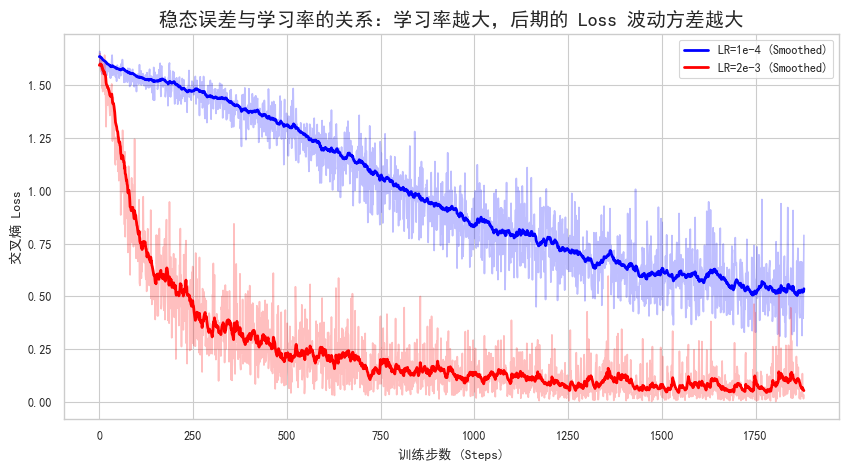

In [4]:
# 固定Batch Size=32，改变学习率 (为了让前期下降稳定，加大epochs至8)
res_lr_small = run_experiment(batch_size=32, lr=1e-4, epochs=8)
res_lr_large = run_experiment(batch_size=32, lr=2e-3, epochs=8)

plt.figure(figsize=(10, 5), dpi=100)
# 绘制带有透明度的原始散点（以反映真实方差波动）
sns.lineplot(x=res_lr_small['steps'], y=res_lr_small['losses'], alpha=0.25, color='blue')
sns.lineplot(x=res_lr_large['steps'], y=res_lr_large['losses'], alpha=0.25, color='red')

# 绘制平滑曲线（以反映均值）
sns.lineplot(x=res_lr_small['steps'], y=smooth_curve(res_lr_small['losses'], 0.95), color='blue', linewidth=2, label='LR=1e-4 (Smoothed)')
sns.lineplot(x=res_lr_large['steps'], y=smooth_curve(res_lr_large['losses'], 0.9), color='red', linewidth=2, label='LR=2e-3 (Smoothed)')

plt.title('稳态误差与学习率的关系：学习率越大，后期的 Loss 波动方差越大', fontsize=14)
plt.xlabel('训练步数 (Steps)')
plt.ylabel('交叉熵 Loss')
plt.legend()
plt.show()


## 实验二：稳态误差与 Batch Size 的关系
**核心理论（公式38 & 57）**：Mini-Batch 机制将梯度方差缩小为单样本SGD的 $1/B$。即**Batch Size 越大，梯度估计越准确，稳态方差越小**。

我们固定 $\eta=5 \times 10^{-4}$，对比 $B=16$（小Batch）与 $B=128$（大Batch）的 Loss 曲线方差。


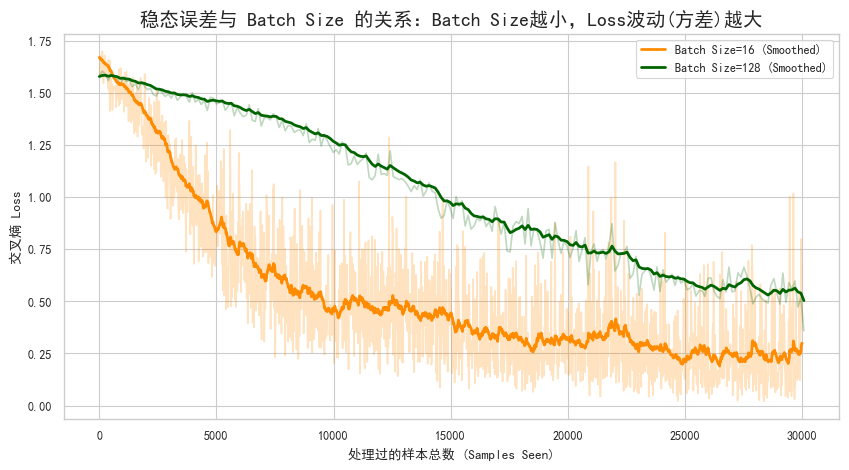

In [5]:
# 固定学习率，改变Batch Size
res_bs_small = run_experiment(batch_size=16, lr=5e-4, epochs=4)
res_bs_large = run_experiment(batch_size=128, lr=5e-4, epochs=4)

# 注意：Batch Size 不同会导致相同的 Epoch 有不同的总 Step 数。为公平对比，我们按「看过的样本总数」进行对齐。
samples_small = [step * 16 for step in res_bs_small['steps']]
samples_large = [step * 128 for step in res_bs_large['steps']]

plt.figure(figsize=(10, 5), dpi=100)
sns.lineplot(x=samples_small, y=res_bs_small['losses'], alpha=0.25, color='darkorange')
sns.lineplot(x=samples_large, y=res_bs_large['losses'], alpha=0.25, color='darkgreen')

sns.lineplot(x=samples_small, y=smooth_curve(res_bs_small['losses'], 0.95), color='darkorange', linewidth=2, label='Batch Size=16 (Smoothed)')
sns.lineplot(x=samples_large, y=smooth_curve(res_bs_large['losses'], 0.8), color='darkgreen', linewidth=2, label='Batch Size=128 (Smoothed)')

plt.title('稳态误差与 Batch Size 的关系：Batch Size越小，Loss波动(方差)越大', fontsize=14)
plt.xlabel('处理过的样本总数 (Samples Seen)')
plt.ylabel('交叉熵 Loss')
plt.legend()
plt.show()


## 实验三：学习率与批大小的线性缩放法则
**核心理论**：如果想让稳态方差 $V_{\infty} \propto \frac{\eta}{B}$ 保持不变，当批大小扩大 $k$ 倍时，学习率可同步扩大 $k$ 倍，以在保证模型收敛精度基本不变的前提下，大幅提升训练速度。

我们测试以下配置对比：
- 配置1：$B=16, \eta=2 \times 10^{-4}$ 
- 配置2：$B=64, \eta=8 \times 10^{-4}$ (均扩大4倍)


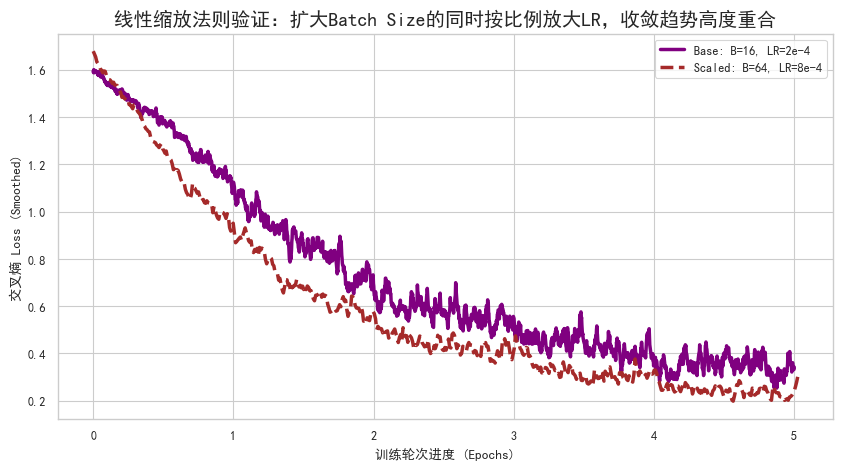

In [6]:
res_base = run_experiment(batch_size=16, lr=2e-4, epochs=5)
res_scaled = run_experiment(batch_size=64, lr=8e-4, epochs=5)

# 按照 Epoch 进度映射进行对齐，方便对比收敛轨迹
epoch_progress_base = [s / (len(full_dataset) / 16) for s in res_base['steps']]
epoch_progress_scaled = [s / (len(full_dataset) / 64) for s in res_scaled['steps']]

plt.figure(figsize=(10, 5), dpi=100)
sns.lineplot(x=epoch_progress_base, y=smooth_curve(res_base['losses'], 0.9), color='purple', linewidth=2.5, label='Base: B=16, LR=2e-4')
sns.lineplot(x=epoch_progress_scaled, y=smooth_curve(res_scaled['losses'], 0.8), color='brown', linewidth=2.5, linestyle='--', label='Scaled: B=64, LR=8e-4')

plt.title('线性缩放法则验证：扩大Batch Size的同时按比例放大LR，收敛趋势高度重合', fontsize=14)
plt.xlabel('训练轮次进度 (Epochs)')
plt.ylabel('交叉熵 Loss (Smoothed)')
plt.legend()
plt.show()


## 实验四：偏差-方差的阶段切换（学习率调度策略的理论底层）
**核心理论**：
- **训练前期**：偏差（曲率的方向不确定性）占主导，需要 Warmup（从小学习率缓慢上升），避免大步长导致的参数震荡发散。
- **训练后期**：观测噪声占主导，稳态方差显现，需要运用学习率衰减（Decay），强行降低稳态误差 $V_{\infty}$，保证最终收敛精度。

对比【恒定学习率】与【Warmup + 余弦衰减 (Cosine Decay) 学习率调度】的效果。


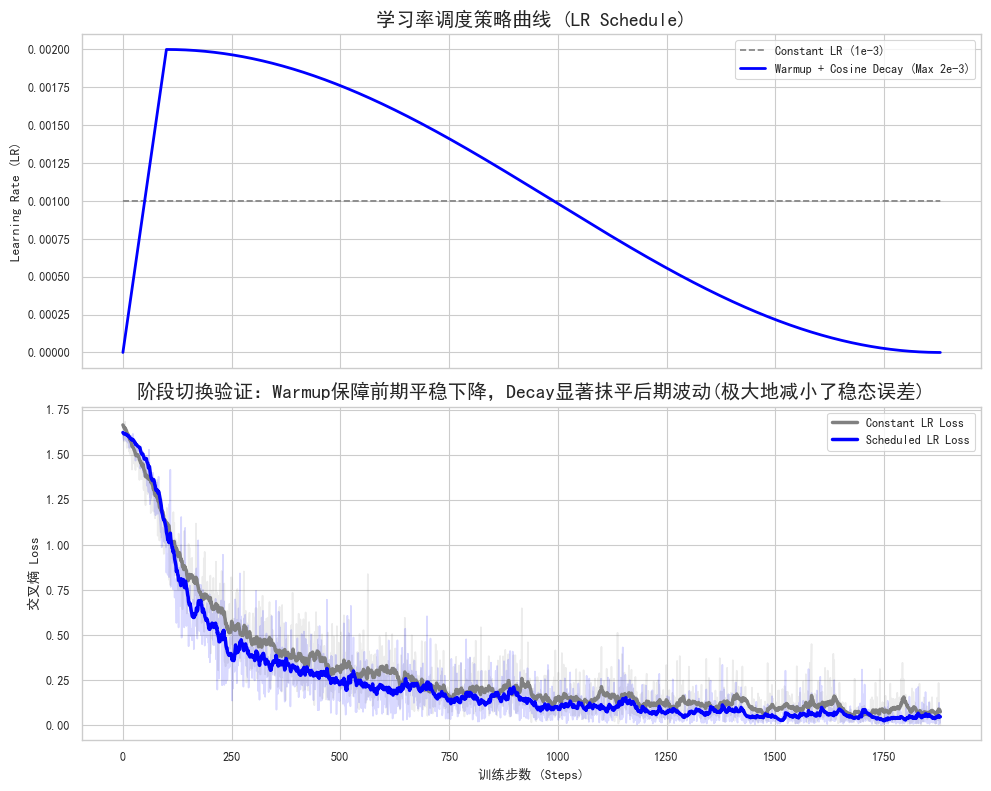

In [7]:
# 根据前期测试调优，加大epoch让Decay过程更完整展现
res_constant = run_experiment(batch_size=32, lr=1e-3, epochs=8, use_scheduler=False)
res_scheduled = run_experiment(batch_size=32, lr=2e-3, epochs=8, use_scheduler=True, warmup_steps=100)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, dpi=100)

# 绘制学习率变化曲线
sns.lineplot(x=res_constant['steps'], y=res_constant['lrs'], ax=ax1, color='gray', linestyle='--', label='Constant LR (1e-3)')
sns.lineplot(x=res_scheduled['steps'], y=res_scheduled['lrs'], ax=ax1, color='blue', linewidth=2, label='Warmup + Cosine Decay (Max 2e-3)')
ax1.set_title('学习率调度策略曲线 (LR Schedule)', fontsize=14)
ax1.set_ylabel('Learning Rate (LR)')
ax1.legend()

# 绘制Loss变化曲线
sns.lineplot(x=res_constant['steps'], y=res_constant['losses'], ax=ax2, alpha=0.15, color='gray')
sns.lineplot(x=res_scheduled['steps'], y=res_scheduled['losses'], ax=ax2, alpha=0.15, color='blue')

sns.lineplot(x=res_constant['steps'], y=smooth_curve(res_constant['losses'], 0.9), ax=ax2, color='gray', linewidth=2.5, label='Constant LR Loss')
sns.lineplot(x=res_scheduled['steps'], y=smooth_curve(res_scheduled['losses'], 0.9), ax=ax2, color='blue', linewidth=2.5, label='Scheduled LR Loss')
ax2.set_title('阶段切换验证：Warmup保障前期平稳下降，Decay显著抹平后期波动(极大地减小了稳态误差)', fontsize=14)
ax2.set_xlabel('训练步数 (Steps)')
ax2.set_ylabel('交叉熵 Loss')
ax2.legend()

plt.tight_layout()
plt.show()
